In [293]:
# ruff: noqa
# Configuring astropt for inference (95m param model)
import glob
from astropt.model_utils import load_astropt
from astropt.local_datasets import GalaxyImageDataset
import torch
import numpy as np
from torchvision import transforms

def normalise(x):
    std, mean = torch.std_mean(x, dim=1, keepdim=True)
    return (x - mean) / (std + 1e-8)

def data_transforms():
    return transforms.Compose([transforms.Lambda(normalise)])

model = load_astropt("Smith42/astroPT_v2.0", path="astropt/095M")

galproc = GalaxyImageDataset(
    None,
    spiral=True,
    transform={"images": data_transforms()},
    modality_registry=model.modality_registry
)

number of parameters: 95.18M
model loaded successfully from Smith42/astroPT_v2.0/astropt/095M
args: {'n_layer': 12, 'n_head': 12, 'n_embd': 768, 'n_chan': 3, 'block_size': 1024, 'dropout': 0.0, 'modalities': [ModalityConfig(name='images', input_size=768, pos_input_size=1, patch_size=16, embed_pos=True, loss_weight=1.0)], 'attn_type': 'causal'}


In [294]:
TORCH_SEED = 4021

In [295]:
import glob
import os
import random
import json

SEED = 42
SOURCE_DIR = "cutouts"
SPLIT_DIR = "cutouts_split"
TRAIN_FRAC = 0.8

files = sorted(glob.glob(f"{SOURCE_DIR}/*.npy"))
random.Random(SEED).shuffle(files)

n_train = int(len(files) * TRAIN_FRAC)
train_files = files[:n_train]
test_files = files[n_train:]

os.makedirs(f"{SPLIT_DIR}/train", exist_ok=True)
os.makedirs(f"{SPLIT_DIR}/test", exist_ok=True)

for f in train_files:
    dst = os.path.join(SPLIT_DIR, "train", os.path.basename(f))
    if not os.path.exists(dst):
        os.symlink(os.path.abspath(f), dst)

for f in test_files:
    dst = os.path.join(SPLIT_DIR, "test", os.path.basename(f))
    if not os.path.exists(dst):
        os.symlink(os.path.abspath(f), dst)

manifest = {
    "seed": SEED,
    "train": [os.path.basename(f) for f in train_files],
    "test": [os.path.basename(f) for f in test_files],
}
with open(f"{SPLIT_DIR}/split_manifest.json", "w") as fh:
    json.dump(manifest, fh, indent=2)

print(f"train: {len(train_files)}, test: {len(test_files)}")

train: 1600, test: 400


In [296]:
import json
import numpy as np
import torch

with open("cutouts_split/split_manifest.json") as fh:
    manifest = json.load(fh)

train_files = [f"cutouts_split/train/{name}" for name in manifest["train"]]

def embed_baseline(npy_path):
    g, r, z = np.asarray(np.load(npy_path, allow_pickle=True).item()["flux"], dtype=np.float32)
    rgb = np.stack([g, r, z], axis=-1)
    rgb = np.arcsinh(rgb / np.percentile(rgb, 99.5))
    rgb = np.clip(rgb / rgb.max(), 0, 1)

    img = np.pad(rgb, ((4, 4), (4, 4), (0, 0)), mode="reflect")
    galaxy = galproc.process_galaxy(
        torch.from_numpy(img.swapaxes(0, 2)).to(float)
    ).to(torch.float)
    positions = torch.arange(0, len(galaxy), dtype=torch.long)
    batch = {"images": galaxy.unsqueeze(0), "images_positions": positions.unsqueeze(0)}
    with torch.no_grad():
        return model.generate_embeddings(batch)["images"].detach().numpy()

train_embeddings = np.concatenate([embed_baseline(f) for f in train_files])
np.save("train_embeddings_baseline.npy", train_embeddings)
print(train_embeddings.shape)

(1600, 768)


In [297]:
import os
import pandas as pd
import numpy as np
import torch.nn as nn
import csv

meta = pd.read_parquet("sample_2k_matches_metadata.parquet").set_index("_healpix_29")

train_ids = [int(os.path.splitext(name)[0]) for name in manifest["train"]]
train_targets = meta.loc[train_ids, "LOG_MSTAR_mmu_desi_provabgs"].values.astype(np.float32)

target_mean, target_std = train_targets.mean(), train_targets.std()
train_targets_norm = (train_targets - target_mean) / target_std

n_val = int(len(train_embeddings) * 0.15)
X_train, X_val = train_embeddings[n_val:], train_embeddings[:n_val]
y_train, y_val = train_targets_norm[n_val:], train_targets_norm[:n_val]

X_train_t = torch.from_numpy(X_train).float()
y_train_t = torch.from_numpy(y_train).float().unsqueeze(1)
X_val_t = torch.from_numpy(X_val).float()
y_val_t = torch.from_numpy(y_val).float().unsqueeze(1)

embed_dim = X_train.shape[1]
torch.manual_seed(TORCH_SEED)
probe = nn.Linear(embed_dim, 1)
optimizer = torch.optim.Adam(probe.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

best_val_loss = float("inf")
patience, patience_counter = 20, 0
max_epochs = 200

with open("training_log_baseline.csv", "w", newline="") as fh:
    writer = csv.writer(fh)
    writer.writerow(["epoch", "train_loss", "val_loss"])

    for epoch in range(max_epochs):
        probe.train()
        optimizer.zero_grad()
        train_pred = probe(X_train_t)
        train_loss = loss_fn(train_pred, y_train_t)
        train_loss.backward()
        optimizer.step()

        probe.eval()
        with torch.no_grad():
            val_pred = probe(X_val_t)
            val_loss = loss_fn(val_pred, y_val_t)

        writer.writerow([epoch, train_loss.item(), val_loss.item()])

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            patience_counter = 0
            torch.save(probe.state_dict(), "probe_baseline_best.pt")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"early stopping at epoch {epoch}")
                break

     epoch  train_loss  val_loss
195    195    0.537406  0.604963
196    196    0.536438  0.604297
197    197    0.535478  0.603639
198    198    0.534525  0.602988
199    199    0.533581  0.602346
final train_loss: 0.5336, final val_loss: 0.6023
num epochs run: 200


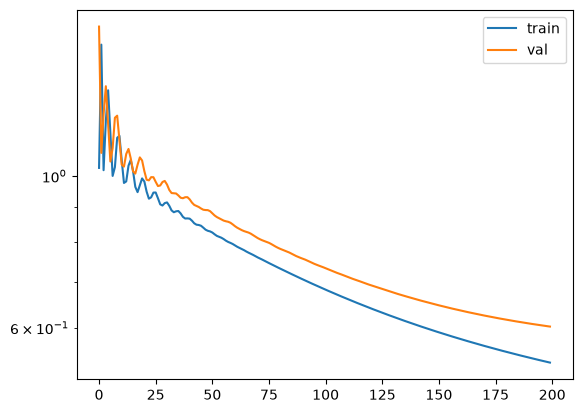

In [298]:
import matplotlib.pyplot as plt
import pandas as pd

log = pd.read_csv("training_log_baseline.csv")
print(log.tail())
print(f"final train_loss: {log['train_loss'].iloc[-1]:.4f}, final val_loss: {log['val_loss'].iloc[-1]:.4f}")
print(f"num epochs run: {len(log)}")
plt.plot(log["epoch"], log["train_loss"], label="train")
plt.plot(log["epoch"], log["val_loss"], label="val")
plt.legend(); plt.yscale("log")
plt.show()

In [299]:
import torch.nn as nn
from scipy.stats import pearsonr
import json

test_files = [f"cutouts_split/test/{name}" for name in manifest["test"]]
test_embeddings = np.concatenate([embed_baseline(f) for f in test_files])

test_ids = [int(os.path.splitext(name)[0]) for name in manifest["test"]]
test_targets = meta.loc[test_ids, "LOG_MSTAR_mmu_desi_provabgs"].values.astype(np.float32)

test_targets_norm = (test_targets - target_mean) / target_std

probe_eval = nn.Linear(embed_dim, 1)
probe_eval.load_state_dict(torch.load("probe_baseline_best.pt"))
probe_eval.eval()

X_test_t = torch.from_numpy(test_embeddings).float()
with torch.no_grad():
    pred_norm = probe_eval(X_test_t).squeeze(1).numpy()

pred = pred_norm * target_std + target_mean

mae = np.mean(np.abs(pred - test_targets))
rmse = np.sqrt(np.mean((pred - test_targets) ** 2))
r2 = 1 - np.sum((pred - test_targets) ** 2) / np.sum((test_targets - test_targets.mean()) ** 2)
pearson_r, _ = pearsonr(pred, test_targets)

summary = {"mae": float(mae), "rmse": float(rmse), "r2": float(r2), "pearson_r": float(pearson_r), "n_test": len(test_targets)}
os.makedirs(f"linear_probe_results/seed_{TORCH_SEED}", exist_ok=True)
with open(f"linear_probe_results/seed_{TORCH_SEED}/eval_summary_baseline.json", "w") as fh:
    json.dump(summary, fh, indent=2)

print(summary)

{'mae': 0.3892383873462677, 'rmse': 0.5052827000617981, 'r2': 0.3693341612815857, 'pearson_r': 0.6189721822738647, 'n_test': 400}


## Attention-augmented

In [ ]:
from scripts.galaxy_dino import get_attention_map

def embed_attention(npy_path):
    g, r, z = np.asarray(np.load(npy_path, allow_pickle=True).item()["flux"], dtype=np.float32)
    rgb = np.stack([g, r, z], axis=-1)
    rgb = np.arcsinh(rgb / np.percentile(rgb, 99.5))
    rgb = np.clip(rgb / rgb.max(), 0, 1)

    attn_map = get_attention_map(rgb, out_size=rgb.shape[:2])
    rgb = rgb * attn_map[..., None]

    img = np.pad(rgb, ((4, 4), (4, 4), (0, 0)), mode="reflect")
    galaxy = galproc.process_galaxy(
        torch.from_numpy(img.swapaxes(0, 2)).to(float)
    ).to(torch.float)
    positions = torch.arange(0, len(galaxy), dtype=torch.long)
    batch = {"images": galaxy.unsqueeze(0), "images_positions": positions.unsqueeze(0)}
    with torch.no_grad():
        return model.generate_embeddings(batch)["images"].detach().numpy()

In [301]:
train_embeddings_attn = np.concatenate([embed_attention(f) for f in train_files])
np.save("train_embeddings_attention.npy", train_embeddings_attn)
print(train_embeddings_attn.shape)

(1600, 768)


In [302]:
X_train, X_val = train_embeddings_attn[n_val:], train_embeddings_attn[:n_val]
# y_train, y_val, target_mean, target_std stay the same — same targets, same split, same normalization

torch.manual_seed(TORCH_SEED)   
probe_attn = nn.Linear(embed_dim, 1)
optimizer = torch.optim.Adam(probe_attn.parameters(), lr=1e-3)

best_val_loss = float("inf")
patience_counter = 0

with open("training_log_attention.csv", "w", newline="") as fh:
    writer = csv.writer(fh)
    writer.writerow(["epoch", "train_loss", "val_loss"])
    for epoch in range(max_epochs):
        probe_attn.train()
        optimizer.zero_grad()
        train_pred = probe_attn(torch.from_numpy(X_train).float())
        train_loss = loss_fn(train_pred, y_train_t)
        train_loss.backward()
        optimizer.step()

        probe_attn.eval()
        with torch.no_grad():
            val_pred = probe_attn(torch.from_numpy(X_val).float())
            val_loss = loss_fn(val_pred, y_val_t)

        writer.writerow([epoch, train_loss.item(), val_loss.item()])
        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            patience_counter = 0
            torch.save(probe_attn.state_dict(), "probe_attention_best.pt")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"early stopping at epoch {epoch}")
                break

     epoch  train_loss  val_loss
195    195    0.471737  0.570656
196    196    0.470947  0.570108
197    197    0.470162  0.569564
198    198    0.469383  0.569027
199    199    0.468610  0.568499
final train_loss: 0.4686, final val_loss: 0.5685
num epochs run: 200


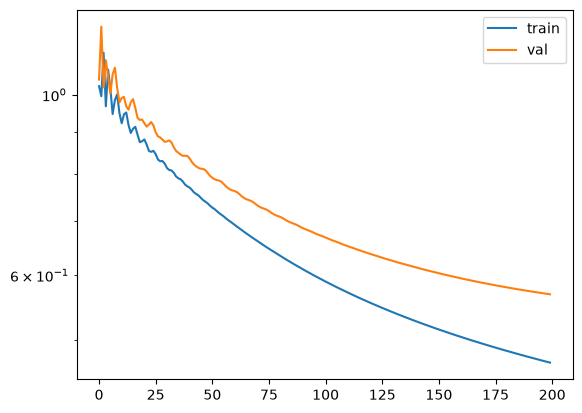

In [303]:
import matplotlib.pyplot as plt
import pandas as pd

log = pd.read_csv("training_log_attention.csv")
print(log.tail())
print(f"final train_loss: {log['train_loss'].iloc[-1]:.4f}, final val_loss: {log['val_loss'].iloc[-1]:.4f}")
print(f"num epochs run: {len(log)}")
plt.plot(log["epoch"], log["train_loss"], label="train")
plt.plot(log["epoch"], log["val_loss"], label="val")
plt.legend(); plt.yscale("log")
plt.show()

In [304]:
test_embeddings_attn = np.concatenate([embed_attention(f) for f in test_files])


probe_attn_eval = nn.Linear(embed_dim, 1)
probe_attn_eval.load_state_dict(torch.load("probe_attention_best.pt"))
probe_attn_eval.eval()

with torch.no_grad():
    pred_norm = probe_attn_eval(torch.from_numpy(test_embeddings_attn).float()).squeeze(1).numpy()
pred = pred_norm * target_std + target_mean

mae = np.mean(np.abs(pred - test_targets))
rmse = np.sqrt(np.mean((pred - test_targets) ** 2))
r2 = 1 - np.sum((pred - test_targets) ** 2) / np.sum((test_targets - test_targets.mean()) ** 2)
pearson_r, _ = pearsonr(pred, test_targets)

summary_attn = {"mae": float(mae), "rmse": float(rmse), "r2": float(r2), "pearson_r": float(pearson_r), "n_test": len(test_targets)}
with open(f"linear_probe_results/seed_{TORCH_SEED}/eval_summary_attention.json", "w") as fh:
    json.dump(summary_attn, fh, indent=2)
print(summary_attn)

{'mae': 0.3746861219406128, 'rmse': 0.49826112389564514, 'r2': 0.3867403268814087, 'pearson_r': 0.623711347579956, 'n_test': 400}


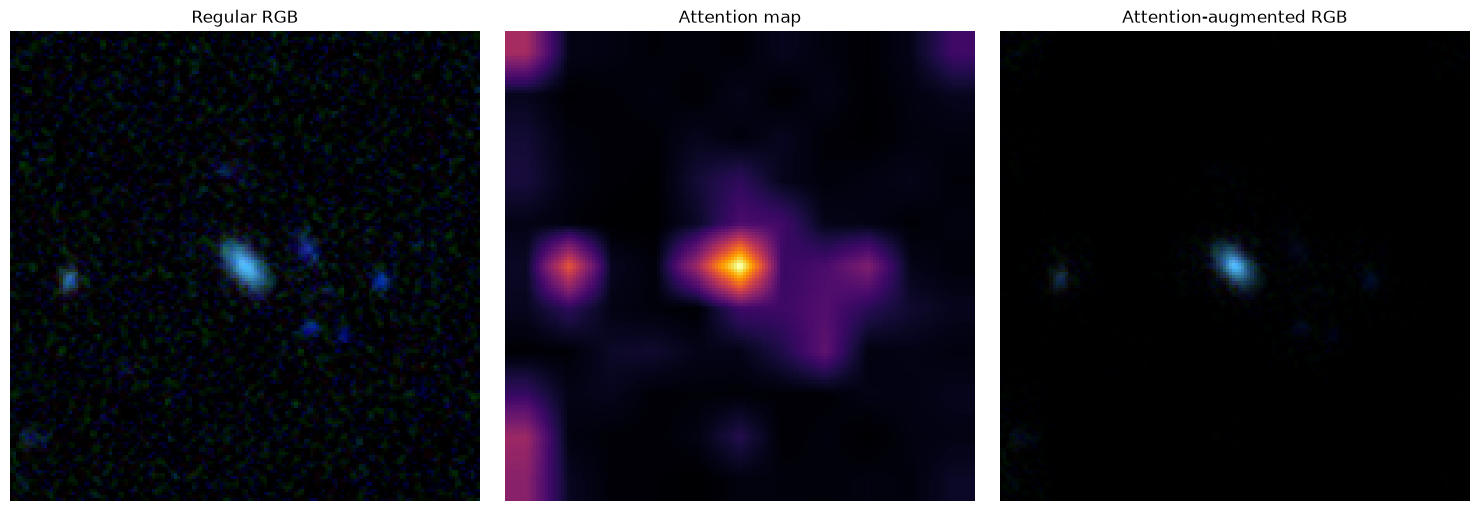

In [323]:
import random

sample_file = random.choice(train_files)

g, r, z = np.asarray(np.load(sample_file, allow_pickle=True).item()["flux"], dtype=np.float32)
rgb = np.stack([g, r, z], axis=-1)
rgb = np.arcsinh(rgb / np.percentile(rgb, 99.5))
rgb = np.clip(rgb / rgb.max(), 0, 1)

attn_map = get_attention_map(rgb, out_size=rgb.shape[:2])
rgb_augmented = rgb * attn_map[..., None]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rgb, origin="lower")
axes[0].set_title("Regular RGB")
axes[0].axis("off")

axes[1].imshow(attn_map, cmap="inferno", origin="lower")
axes[1].set_title("Attention map")
axes[1].axis("off")

axes[2].imshow(rgb_augmented, origin="lower")
axes[2].set_title("Attention-augmented RGB")
axes[2].axis("off")

plt.tight_layout()
plt.show()

| Metric | Baseline | Attention | Δ | p-value |
|---|---|---|---|---|
| MAE | 0.3962 | 0.3894 | -0.0068 | 0.00091 |
| RMSE | 0.5126* | 0.5115* | -0.0011 | 0.514 |
| R² | 0.3505* | 0.3534* | +0.0029 | 0.496 |
| Pearson r | 0.6055* | 0.5994* | -0.0061 | 0.078 |

*mean across seeds
